<a href="https://colab.research.google.com/github/araj1010/Adaptive-Inference-Engine-for-Resource-Constrained-Wearable-Devices/blob/main/04_gating_mechanism.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook implements an adaptive inference system that:


*   Uses a lightweight model for easy samples
*   Uses a complex model for hard samples
*   Reduces computation while maintaining high accuracy

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
BASE_PATH = "/content/drive/MyDrive/Adaptive_Inference_Project"

# 📥 Load Test Data

In [ ]:
import numpy as np

X_test = np.load(f"{BASE_PATH}/processed_data/X_test.npy")
y_test = np.load(f"{BASE_PATH}/processed_data/y_test.npy")

print("Test data loaded:", X_test.shape)

Test data loaded: (2947, 561)


# 📦 Load Trained Models

Lightweight model → Logistic Regression  
Complex model → Random Forest

In [ ]:
import joblib

lr_model = joblib.load(f"{BASE_PATH}/models/logistic_regression.pkl")
rf_model = joblib.load(f"{BASE_PATH}/models/random_forest.pkl")

print("Models loaded successfully")

Models loaded successfully


# 📊 Load Confidence Scores (from Notebook-3)

In [ ]:
lr_confidence = np.load(f"{BASE_PATH}/confidence_outputs/lr_confidence.npy")
print("Confidence loaded:", lr_confidence.shape)

Confidence loaded: (2947,)


# 🧠 Adaptive Gating Logic
Rule:

If Logistic Regression confidence ≥ threshold
→ Accept LR prediction

Else
→ Use Random Forest prediction

# ⚙️ Define Threshold

In [ ]:
CONFIDENCE_THRESHOLD = 0.8

# 🔮 Get Predictions

In [ ]:
lr_preds = lr_model.predict(X_test)
rf_preds = rf_model.predict(X_test)

# 🚦 Implement Gating Mechanism

In [ ]:
adaptive_predictions = []

for i in range(len(X_test)):
    if lr_confidence[i] >= CONFIDENCE_THRESHOLD:
        adaptive_predictions.append(lr_preds[i])
    else:
        adaptive_predictions.append(rf_preds[i])

adaptive_predictions = np.array(adaptive_predictions)

print("Adaptive inference completed")

Adaptive inference completed


# 📈 Evaluate Adaptive System

In [ ]:
from sklearn.metrics import accuracy_score

adaptive_accuracy = accuracy_score(y_test, adaptive_predictions)

print("Adaptive Model Accuracy:", adaptive_accuracy)

Adaptive Model Accuracy: 0.9565659993213438


# 📊 Compare with Individual Models

In [ ]:
lr_accuracy = accuracy_score(y_test, lr_preds)
rf_accuracy = accuracy_score(y_test, rf_preds)

print("Logistic Regression Accuracy:", lr_accuracy)
print("Random Forest Accuracy:", rf_accuracy)
print("Adaptive System Accuracy:", adaptive_accuracy)

Logistic Regression Accuracy: 0.9552086868001357
Random Forest Accuracy: 0.9260264675941635
Adaptive System Accuracy: 0.9565659993213438


# ⚡Computation Reduction Analysis
Count how many samples used lightweight model.

In [ ]:
easy_samples = np.sum(lr_confidence >= CONFIDENCE_THRESHOLD)
hard_samples = len(X_test) - easy_samples

print("Samples handled by LR (fast):", easy_samples)
print("Samples escalated to RF (complex):", hard_samples)
print("Percentage using lightweight model:",
      (easy_samples / len(X_test)) * 100, "%")

Samples handled by LR (fast): 2781
Samples escalated to RF (complex): 166
Percentage using lightweight model: 94.36715303698676 %


## 📊 Visualization: Model Usage

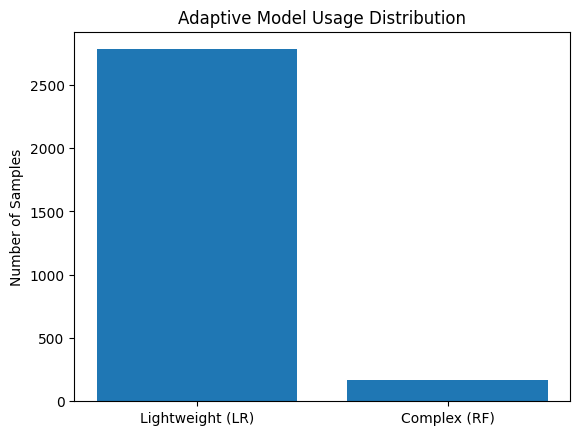

In [ ]:
import matplotlib.pyplot as plt

labels = ["Lightweight (LR)", "Complex (RF)"]
values = [easy_samples, hard_samples]

plt.figure()
plt.bar(labels, values)
plt.title("Adaptive Model Usage Distribution")
plt.ylabel("Number of Samples")
plt.show()

# 🔁 Threshold Sensitivity Analysis

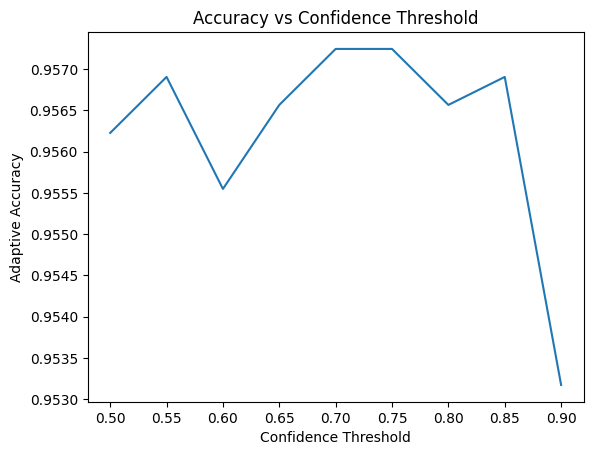

In [ ]:
thresholds = np.arange(0.5, 0.95, 0.05)
adaptive_accuracies = []

for t in thresholds:
    temp_preds = []

    for i in range(len(X_test)):
        if lr_confidence[i] >= t:
            temp_preds.append(lr_preds[i])
        else:
            temp_preds.append(rf_preds[i])

    adaptive_accuracies.append(
        accuracy_score(y_test, temp_preds)
    )

plt.figure()
plt.plot(thresholds, adaptive_accuracies)
plt.title("Accuracy vs Confidence Threshold")
plt.xlabel("Confidence Threshold")
plt.ylabel("Adaptive Accuracy")
plt.show()